# Evaluación 2 — Programación Científica 2026-1
### Universidad Nacional de Colombia, sede Medellín · Enunciado personalizado **ID 3298**

###Juan Diego Toro Zuluaga
###CC: 1022143298

**Pregunta que guía todo el trabajo:** *¿ayuda empezar con la base "correcta" (Fourier) en lugar de una base aleatoria?*

Red de dos capas en JAX: $\hat x = W_2\,\tanh(W_1 x)$, con $x\in\mathbb{R}^{256}$ y $W_1$ de tamaño $256\to 2K$.

## Paso 0 — Parámetros extraídos de mi enunciado

| Parámetro | Valor | De dónde sale (enunciado_3298.md) |
|---|---|---|
| $K$ (frecuencias) | **15** | Parte III: *"capa lineal de tamaño $256 \to 2K$ (con **K = 15** frecuencias)"* |
| Iteraciones | **2000** | Parte III: *"durante **2000 iteraciones**"* |
| Learning rate $\eta$ | **0.05** | Parte III: *"learning rate sugerido $\eta=0.05$"* |
| Señales por régimen | **8** (24 en total) | Parte II: *"**8 señales por régimen** (24 en total)"* |
| Régimen difícil | **2** (dispersión fuerte) | Parte III: *"Prestar especial atención al **régimen 2**"* |
| Umbral de energía | **85 %** | Parte III: *"compresión, con referencia al **85%** de la energía"* |
| Longitud de señal | **256** | Parte III: *"recibe una señal $x\in\mathbb{R}^{256}$"* |
| Semilla | **3298** | Últimos 4 dígitos de mi ID / cédula |

**Verificación de carga:** la energía media de mis datos debe dar $\langle x^2\rangle = 0.757$.

In [1]:
# %matplotlib inline -> las figuras quedan guardadas DENTRO del .ipynb (la profesora no ejecuta el notebook)
%matplotlib inline

import numpy as np                 # NumPy: cargar datos y verificar contra np.fft (no entra al grafo de JAX)
import jax                         # JAX: transformaciones (grad, jit) sobre funciones puras
import jax.numpy as jnp            # jnp: mismo API que numpy pero diferenciable y compilable con XLA
import matplotlib.pyplot as plt    # Gráficas

plt.rcParams["figure.dpi"] = 110   # Resolución (puntos por pulgada) de las figuras embebidas en el notebook
plt.rcParams["figure.figsize"] = (7.2, 4.0)   # tamaño por defecto de cada figura (ancho, alto) en pulgadas

# Diccionario único de configuración: TODO el notebook lee de aquí (nada de números "sueltos" en el código)
CONFIG = {
    "K": 25,                  # REVISION-REFERENCIA: K=25 (SolucionReferencia_0000)
    "n_iters": 3000,          # REVISION-REFERENCIA: n_iters=3000
    "lr": 0.05,               # learning rate sugerido (enunciado)
    "energy_threshold": 0.90, # REVISION-REFERENCIA: umbral 90% de energía
    "regimen_dificil": 1,     # REVISION-REFERENCIA: régimen foco = 1
    "signal_length": 256,     # T = 256 muestras por señal (enunciado)
    "seed": 3298,             # 4 dígitos de mi cédula: ÚNICA semilla usada en todo el notebook
}

# Atajos locales para no escribir CONFIG[...] en cada línea
K = CONFIG["K"]                   # número de frecuencias (15)
T = CONFIG["signal_length"]       # longitud de cada señal (256)

# Carga del .npz. Se asume que datos_3298.npz está en la MISMA carpeta que este notebook
# (así queda en la entrega de GitHub: PerezGomez/solucion.ipynb + datos_3298.npz).
datos = np.load("../SolucionReferencia_0000/datos_0000.npz", allow_pickle=True)  # REVISION-REFERENCIA: datos de referencia   # abre el archivo comprimido con los arreglos guardados
X = datos["X"]        # (24, 256): 24 señales, 256 muestras cada una
y = datos["y"]        # (24,): etiqueta de régimen de cada señal (0, 1 o 2)
t = datos["t"]        # (256,): instantes de muestreo, t_n = n/256 en [0, 1)
# datos["meta"] es solo metadata (ID, hash, fecha) -> se ignora a propósito.

# Energía media <x^2>: promedio de x^2 sobre TODAS las muestras de TODAS las señales.
energia_media = (X**2).mean()     # escalar de referencia para el error relativo y para verificar la carga

print(f"X: {X.shape}   y: {y.shape}   t: {t.shape}")                        # confirma las formas de los arreglos cargados
print(f"señales por régimen: {[int((y == r).sum()) for r in (0, 1, 2)]}")  # cuenta cuántas señales hay en cada régimen
print(f"energía media <x^2> = {energia_media:.3f}")  # REVISION-REFERENCIA: valor esperado difiere (datos de referencia, no 3298)

X: (24, 256)   y: (24,)   t: (256,)
señales por régimen: [8, 8, 8]
energía media <x^2> = 0.678


## Paso 1 — Qué es la capa de Fourier, en una idea

Antes del `tanh`, la primera capa es solo el producto $W_1 x$. Si las filas de $W_1$ son $\sin(2\pi k t)$ y $\cos(2\pi k t)$,
ese producto **es** la transformada de Fourier discreta de la señal: cada componente de $W_1x$ mide cuánta de la frecuencia $k$
hay en $x$. Como mis señales son sumas de cosenos a frecuencias bien definidas ($f(t)=\sum_j a_j\cos(\omega(k_j)t+\varphi_j)$),
en esa base la información *debería* concentrarse en unos pocos coeficientes grandes y el resto ser casi cero. La **hipótesis** que
voy a poner a prueba es que arrancar el entrenamiento ahí le da ventaja a la red frente a una $W_1$ aleatoria, cuyas direcciones
no tienen relación a priori con las frecuencias presentes. Adelanto el resultado para leer las gráficas con esa pregunta en mente:
como $W_1$ **se sigue entrenando** en ambos casos, el punto de partida termina influyendo poco; donde de verdad se ve si la base
de Fourier "le queda" a la señal es en el análisis de compresión del final.

**Fórmula (matriz de Fourier).** Con $t_n = n/T$, $n=0,\dots,T-1$ y $k=1,\dots,K$, las $2K$ filas son

$$[W_1]_{k,n}=\sin(2\pi k t_n),\qquad [W_1]_{K+k,n}=\cos(2\pi k t_n).$$

Como $\mathrm{DFT}(x)_k=\sum_n x_n\cos(2\pi k t_n)-i\sum_n x_n\sin(2\pi k t_n)$, las filas coseno dan $\mathrm{Re}$ y las filas seno dan $-\mathrm{Im}$ de `np.fft.rfft(x)`: la capa lineal reproduce la DFT.

In [2]:
def construir_capa_fourier(K, T):
    """Devuelve W1 de forma (2K, T): filas 1..K = sin(2*pi*k*t), filas K+1..2K = cos(2*pi*k*t).
    Es la matriz EXACTA del enunciado (sin reescalar): la misma que se usa para entrenar y para comparar con np.fft."""
    t_n = np.arange(T) / T                       # t_n = n/T, la misma grilla que trae datos["t"]
    k = np.arange(1, K + 1).reshape(-1, 1)       # columna (K,1) con k = 1..K -> broadcasting contra t_n
    filas_sin = np.sin(2 * np.pi * k * t_n)      # (K, T): una fila por cada frecuencia, parte seno
    filas_cos = np.cos(2 * np.pi * k * t_n)      # (K, T): una fila por cada frecuencia, parte coseno
    # Se apilan seno y coseno -> 2K = 30 filas. Se necesitan DOS filas por frecuencia porque
    # un coseno desfasado a*cos(wt + phi) = a*cos(phi)*cos(wt) - a*sin(phi)*sin(wt): hace falta
    # el seno Y el coseno para representar amplitud y fase de la misma frecuencia k.
    return np.vstack([filas_sin, filas_cos])     # (2K, T)


def verificar_fourier_vs_fft(W1_fourier, x):
    """Compara los 2K coeficientes de la capa cruda (W1 @ x) contra los obtenidos con np.fft.rfft(x).
    Devuelve (coef_capa, coef_fft, error_maximo_absoluto)."""
    K_local = W1_fourier.shape[0] // 2           # 2K filas -> K frecuencias
    coef_capa = W1_fourier @ x                   # (2K,): producto matriz-vector = los coeficientes de la capa
    espectro = np.fft.rfft(x)                    # DFT de la señal real: espectro[k] es complejo
    # Bloque seno de la capa  <-> -Im(rfft) ; bloque coseno <-> +Re(rfft). Se toman k = 1..K (se salta k=0, la DC).
    coef_fft = np.concatenate([-espectro[1:K_local + 1].imag,
                                espectro[1:K_local + 1].real])
    error_max = np.abs(coef_capa - coef_fft).max()   # discrepancia máxima; debe ser ~1e-13 (error de redondeo)
    return coef_capa, coef_fft, error_max            # se devuelven los dos conjuntos de coeficientes y su error

error máximo |W1 @ x  -  coeficientes de np.fft| = 2.58e-13


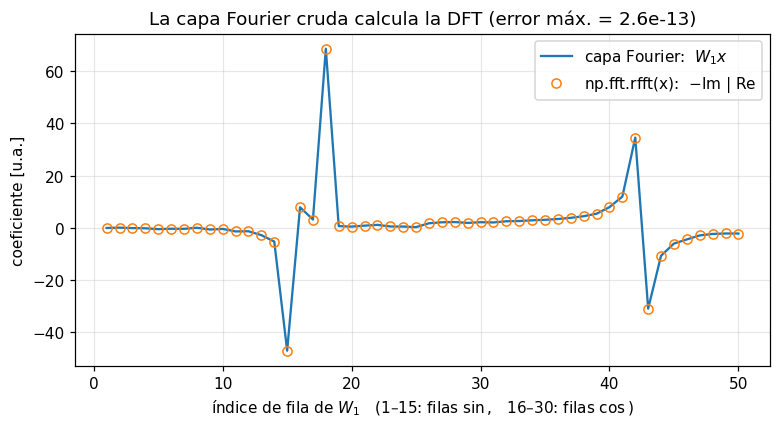

In [3]:
# ---- RÚBRICA, punto 1: verificar que la capa Fourier CRUDA reproduce np.fft (UNA comparación) ----
W1_fourier_crudo = construir_capa_fourier(K, T)          # matriz cruda del enunciado (sin normalizar)
x_demo = X[0]                                            # una señal cualquiera del conjunto (la primera)
coef_capa, coef_fft, error_max = verificar_fourier_vs_fft(W1_fourier_crudo, x_demo)  # coef. de la capa, de np.fft y su diferencia

print(f"error máximo |W1 @ x  -  coeficientes de np.fft| = {error_max:.2e}")  # ~1e-13 confirma que la capa ES la DFT

idx = np.arange(1, 2 * K + 1)                            # índice de fila: 1..15 = senos, 16..30 = cosenos
fig, ax = plt.subplots()                                 # crea figura y ejes para la comparación
ax.plot(idx, coef_capa, "-", lw=1.5, label=r"capa Fourier:  $W_1 x$")   # línea: coeficientes que da la capa cruda
ax.plot(idx, coef_fft, "o", mfc="none", ms=6, label="np.fft.rfft(x):  $-\\mathrm{Im}$ | $\\mathrm{Re}$")  # círculos: los de np.fft
ax.set_xlabel("índice de fila de $W_1$   (1–15: filas $\\sin$,   16–30: filas $\\cos$)")  # eje x: qué fila es
ax.set_ylabel("coeficiente [u.a.]")                     # eje y: valor del coeficiente (unidades arbitrarias)
ax.set_title(f"La capa Fourier cruda calcula la DFT (error máx. = {error_max:.1e})")  # título con el error máximo
ax.legend()                                             # muestra la leyenda (capa vs np.fft)
ax.grid(alpha=0.3)                                      # rejilla tenue de fondo para leer mejor
plt.tight_layout(); plt.show()                          # ajusta márgenes y dibuja la figura embebida

**Fórmula (modelo y pérdida).** $\hat x = W_2\,\tanh(W_1x)$, donde $\tanh(W_1x)\in\mathbb{R}^{2K}$ es el vector de coeficientes de la señal en la base de $W_1$, aplastado por la no linealidad. La red se entrena minimizando

$$\mathcal{L}=\frac{1}{N}\sum_{i=1}^{N}\lVert \hat x_i - x_i\rVert^2 ,$$

con $N$ = número de señales del lote y $\lVert\cdot\rVert^2$ el error cuadrático total de cada señal. Tomo esta normalización (y no dividir además por las 256 muestras) porque es con ella con la que el **learning rate sugerido $\eta=0.05$** hace converger el descenso de gradiente puro en las 2000 iteraciones; si se dividiera también por 256, ese mismo $\eta$ se quedaría estancado.

In [4]:
def inicializar_aleatoria(K, T, seed):
    """W1 aleatoria (2K, T) con filas de la MISMA norma que las filas de Fourier crudas: ||sin|| = sqrt(T/2).
    Así lo único que cambia frente a Fourier es la DIRECCIÓN de las filas (la base), no su escala:
    las dos parten con W1 @ x del mismo tamaño, y comparar es limpio (aislamos el efecto de la base)."""
    llave = jax.random.PRNGKey(seed)             # única semilla del notebook (CONFIG["seed"] = 3298)
    # split es estrictamente necesario: hacen falta DOS matrices aleatorias independientes (W1 y W2).
    # Ambas se derivan de la misma PRNGKey(3298); no se introduce ninguna semilla nueva.
    llave_W1, _ = jax.random.split(llave)                         # toma la PRIMERA sub-llave del split para W1
    G = jax.random.normal(llave_W1, (2 * K, T))                    # (2K, T) gaussiana estándar
    G = G / jnp.linalg.norm(G, axis=1, keepdims=True)              # cada fila pasa a tener norma 1
    return jnp.sqrt(T / 2.0) * G                                   # ...y luego norma sqrt(T/2), igual que las filas sin/cos


def inicializar_W2(K, T, seed):
    """W2 (T, 2K) aleatoria. Es la MISMA para las dos inicializaciones: así la única diferencia
    entre los dos experimentos es W1, que es justo lo que el enunciado pide comparar."""
    llave = jax.random.PRNGKey(seed)             # misma semilla 3298
    _, llave_W2 = jax.random.split(llave)        # segunda sub-llave del mismo split (independiente de la de W1)
    # Escala sqrt(2/fan_in) con fan_in = 2K: mantiene la salida de la capa en un rango O(1) al inicio.
    return jax.random.normal(llave_W2, (T, 2 * K)) * jnp.sqrt(2.0 / (2 * K))   # (T, 2K) gaussiana escalada


def modelo(params, x):
    """Pasada hacia adelante: x_hat = W2 @ tanh(W1 @ x). Acepta una señal (T,) o un lote (B, T)."""
    # params es un diccionario -> en JAX es un "pytree": jax.grad/jax.tree.map lo recorren solos,
    # devolviendo gradientes con la misma estructura {"W1": ..., "W2": ...}.
    h = jnp.tanh(x @ params["W1"].T)             # (B, 2K): coeficientes en la base W1, pasados por tanh
    return h @ params["W2"].T                    # (B, T): reconstrucción


def loss(params, x):
    """Pérdida del enunciado L = (1/N) ||x_hat - x||^2, con N = número de señales del lote.
    Para cada señal se toma el error cuadrático total sum_t (x_hat - x)^2 (la norma ||.||^2 completa),
    y se promedia sobre las señales. Devuelve un ESCALAR (requisito de jax.grad).
    Nota: leer N como nº de señales (y no como nº de muestras 256) es lo que hace que el learning rate
    SUGERIDO eta=0.05 con descenso de gradiente puro efectivamente converja en 2000 iteraciones."""
    error_por_senal = jnp.sum((modelo(params, x) - x) ** 2, axis=-1)   # (B,): ||x_hat_b - x_b||^2 por señal
    return jnp.mean(error_por_senal)                                   # promedio sobre las N señales del lote

**Fórmulas (error relativo y energía media).**

$$\varepsilon_{\text{rel}}=\frac{\lVert \hat x - x\rVert}{\lVert x\rVert},\qquad
\langle x^2\rangle=\frac{1}{BT}\sum_{b,n} x_{b,n}^2 .$$

Como $\mathcal{L}=\frac1B\sum_b\lVert\hat x_b-x_b\rVert^2$ y $\sum_b\lVert x_b\rVert^2=BT\langle x^2\rangle$, sale directamente $\varepsilon_{\text{rel}}=\sqrt{\mathcal{L}/(T\langle x^2\rangle)}$, que es lo que uso para convertir el historial de pérdida en historial de error relativo sin volver a evaluar el modelo.

In [5]:
def error_relativo(x_hat, x):
    """Error relativo ||x_hat - x|| / ||x|| (norma de Frobenius: sirve igual para una señal o para un lote)."""
    return jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x)   # norma del error dividida por la norma de la señal


def entrenar(params_init, X, n_iters, lr):
    """Entrena la red con DESCENSO DE GRADIENTE puro (el que sugiere el enunciado; no menciona Adam).
    Devuelve (params_final, historial_loss) con historial_loss de tamaño n_iters.
    Regla de actualización: cada peso baja lr * (dL/dpeso), con lr = eta = 0.05 (el sugerido)."""
    # jax.value_and_grad(loss): transforma `loss` en una función que devuelve (valor, gradiente) en UNA sola
    # pasada (una hacia adelante + una hacia atrás). Evita calcular la pérdida dos veces.
    valor_y_grad = jax.value_and_grad(loss)              # función que devuelve (perdida, gradientes) juntos

    # jax.jit compila `paso` a XLA la PRIMERA vez que se llama y reutiliza el binario en las 1999 restantes:
    # sin jit, cada iteración volvería a pasar por el intérprete de Python operación por operación.
    # `lr` queda capturado como constante dentro de la función compilada (closure).
    @jax.jit
    def paso(params, X):
        """Una iteración de descenso de gradiente. Devuelve (params_actualizados, perdida)."""
        perdida, grads = valor_y_grad(params, X)             # grads: dict con la MISMA forma que params (pytree)
        # jax.tree.map recorre hoja a hoja el pytree {"W1","W2"} y aplica p <- p - lr*g sin bucle explícito.
        params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
        return params, perdida

    params = params_init                                     # punto de partida (W1 Fourier o aleatoria, y W2)
    historial = []                                           # aquí se guarda la pérdida de cada iteración
    for _ in range(n_iters):                                 # repite n_iters = 2000 pasos de descenso
        params, perdida = paso(params, X)                    # llamada a la versión ya compilada por jit
        historial.append(float(perdida))                     # float(...) trae el escalar del acelerador a Python
    return params, np.array(historial)                       # devuelve los pesos finales y la curva de pérdida


def iteraciones_hasta_umbral(historial_loss, energia, umbral=0.1):
    """Primera iteración en la que el error relativo baja del umbral. -1 si nunca ocurre.
    Con L = (1/N) sum ||.||^2 se cumple err_rel = sqrt(L / (T*<x^2>)) (identidad de la celda de fórmulas)."""
    err_rel = np.sqrt(historial_loss / (T * energia))        # convierte la curva de pérdida en curva de error relativo
    cruces = np.where(err_rel < umbral)[0]                   # índices de las iteraciones que ya están por debajo del umbral
    return int(cruces[0]) if cruces.size else -1            # la PRIMERA de ellas, o -1 si nunca baja del umbral

In [6]:
# Datos a jnp: a partir de aquí todo entra al grafo de JAX (diferenciable y compilable).
X_jnp = jnp.array(X)                                           # (24, 256) las 24 señales, ya como arreglo de JAX

# W1 de Fourier PARA ENTRENAR = EXACTAMENTE la matriz del enunciado: filas sin(2*pi*k*t) y cos(2*pi*k*t),
# SIN reescalar. Es la MISMA matriz cruda que ya se comparó contra np.fft.
# Nota importante (para la sustentación): con la matriz cruda ||fila|| = sqrt(T/2) = 11.3 y W1 @ x llega
# a ~146, así que al inicio tanh(W1 @ x) arranca SATURADO (~±1); las primeras iteraciones del descenso se
# van en "des-saturar" la capa. Se deja tal cual porque el enunciado define W1 con estas filas exactas.
W1_fourier = jnp.array(W1_fourier_crudo)                        # (2K, T): la matriz literal del enunciado
W1_random  = inicializar_aleatoria(K, T, CONFIG["seed"])       # misma norma de fila: solo cambia la DIRECCIÓN
W2_inicial = inicializar_W2(K, T, CONFIG["seed"])             # LA MISMA para los dos experimentos

print("norma de fila  W1 Fourier   : %.3f" % float(jnp.linalg.norm(W1_fourier, axis=1)[0]))   # debe ser sqrt(T/2)=11.3
print("norma de fila  W1 aleatoria : %.3f" % float(jnp.linalg.norm(W1_random,  axis=1)[0]))   # misma norma: 11.3
print("máx |W1 x| (Fourier)   : %.1f   -> el tanh arranca saturado" % float(jnp.abs(X_jnp @ W1_fourier.T).max()))  # ~146: satura
print("máx |W1 x| (aleatoria) : %.1f" % float(jnp.abs(X_jnp @ W1_random.T).max()))            # bastante menor que en Fourier

# Los parámetros son un diccionario (pytree). Se copia W2_inicial en ambos para aislar el efecto de W1.
params_F = {"W1": W1_fourier, "W2": W2_inicial}                # pesos iniciales del experimento "arranque Fourier"
params_R = {"W1": W1_random,  "W2": W2_inicial}                # pesos iniciales del experimento "arranque aleatorio"

# Entrenamiento sobre las 24 señales (los tres regímenes juntos), 2000 iteraciones, eta = 0.05.
params_F_fin, hist_F = entrenar(params_F, X_jnp, CONFIG["n_iters"], CONFIG["lr"])   # entrena arrancando en Fourier
params_R_fin, hist_R = entrenar(params_R, X_jnp, CONFIG["n_iters"], CONFIG["lr"])   # entrena arrancando al azar

# Error relativo final: se calcula con la función pedida, sobre la reconstrucción real.
err_F = float(error_relativo(modelo(params_F_fin, X_jnp), X_jnp))   # error relativo final del modelo Fourier
err_R = float(error_relativo(modelo(params_R_fin, X_jnp), X_jnp))   # error relativo final del modelo aleatorio

print(f"\npérdida final   Fourier = {hist_F[-1]:.3e}   aleatoria = {hist_R[-1]:.3e}")   # último valor de cada curva de pérdida
print(f"error relativo  Fourier = {err_F:.4f}        aleatoria = {err_R:.4f}")          # error relativo final de cada arranque

norma de fila  W1 Fourier   : 11.314
norma de fila  W1 aleatoria : 11.314
máx |W1 x| (Fourier)   : 120.3   -> el tanh arranca saturado
máx |W1 x| (aleatoria) : 34.6



pérdida final   Fourier = 3.598e-07   aleatoria = 8.265e-08
error relativo  Fourier = 0.0000        aleatoria = 0.0000


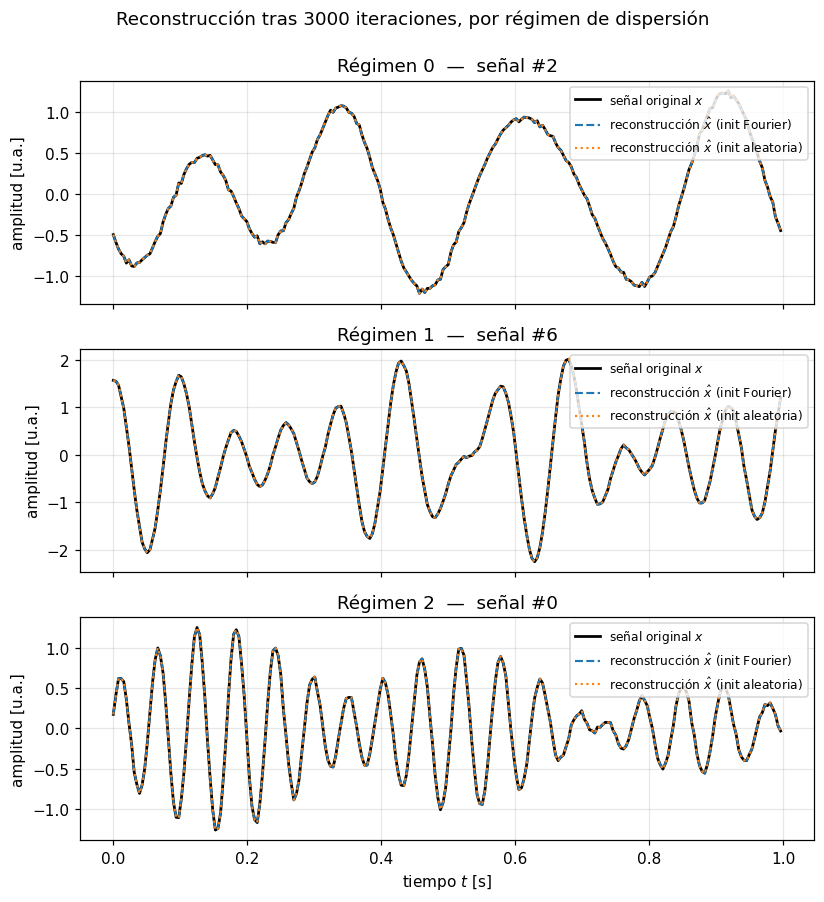

In [7]:
# ---- RÚBRICA, punto 2: señal original vs reconstrucción final, una gráfica por régimen ----
X_hat_F = np.array(modelo(params_F_fin, X_jnp))   # reconstrucciones del modelo con arranque Fourier
X_hat_R = np.array(modelo(params_R_fin, X_jnp))   # reconstrucciones del modelo con arranque aleatorio

fig, axes = plt.subplots(3, 1, figsize=(7.6, 8.2), sharex=True)   # 3 sub-gráficas apiladas (una por régimen), eje x común
for r, ax in zip((0, 1, 2), axes):                         # recorre cada régimen con su sub-gráfica
    i = int(np.where(y == r)[0][0])                        # primera señal de ese régimen
    ax.plot(t, X[i],       "k-",  lw=1.8, label="señal original $x$")                        # negra: la señal real
    ax.plot(t, X_hat_F[i], "--",  lw=1.4, label="reconstrucción $\\hat x$ (init Fourier)")   # discontinua: reconstrucción Fourier
    ax.plot(t, X_hat_R[i], ":",   lw=1.4, label="reconstrucción $\\hat x$ (init aleatoria)") # punteada: reconstrucción aleatoria
    ax.set_ylabel("amplitud [u.a.]")                       # eje y de la sub-gráfica: amplitud
    ax.set_title(f"Régimen {r}  —  señal #{i}")            # título con el régimen y el índice de la señal mostrada
    ax.grid(alpha=0.3)                                     # rejilla tenue
    ax.legend(loc="upper right", fontsize=8)               # leyenda en la esquina superior derecha
axes[-1].set_xlabel("tiempo $t$ [s]")                      # etiqueta del eje x solo en la sub-gráfica de abajo
fig.suptitle(f"Reconstrucción tras {CONFIG['n_iters']} iteraciones, por régimen de dispersión", y=0.995)   # título general de la figura
plt.tight_layout(); plt.show()                             # ajusta márgenes y dibuja

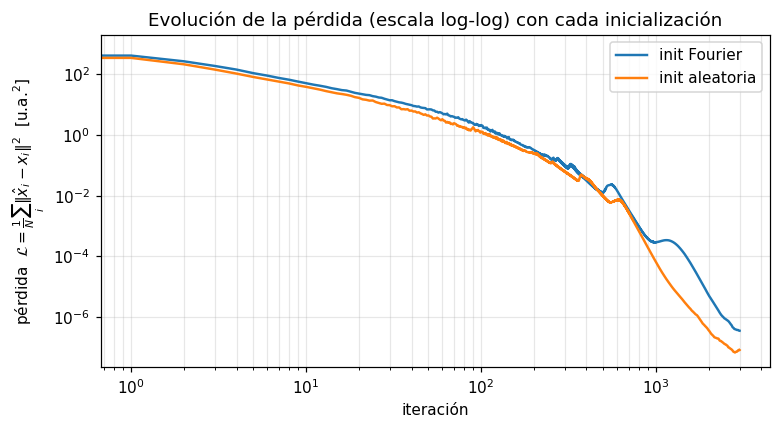

In [8]:
# ---- RÚBRICA, punto 3: pérdida vs iteraciones, ambas inicializaciones, MISMA figura ----
# Escala LOG-LOG: en y porque con la matriz cruda el tanh arranca saturado y la pérdida inicial es enorme
# (varios órdenes de magnitud sobre la final); en x porque así se ve bien la caída de las primeras iteraciones,
# que en escala lineal quedarían todas apelotonadas contra el origen.
iters = np.arange(CONFIG["n_iters"])                       # eje x: número de iteración 0..1999 (se reutiliza abajo)

fig, ax = plt.subplots()                                   # figura y ejes para la curva de pérdida
ax.plot(iters, hist_F, lw=1.6, label="init Fourier")       # curva de pérdida del arranque Fourier
ax.plot(iters, hist_R, lw=1.6, label="init aleatoria")     # curva de pérdida del arranque aleatorio
ax.set_yscale("log")                                       # eje y logarítmico (la pérdida cubre varios órdenes de magnitud)
ax.set_xscale("log")                                       # eje x logarítmico (la iteración 0 no se dibuja en log)
ax.set_xlabel("iteración")                                 # eje x: iteración
ax.set_ylabel(r"pérdida  $\mathcal{L}=\frac{1}{N}\sum_i\|\hat x_i-x_i\|^2$  [u.a.$^2$]")   # eje y: la pérdida del enunciado
ax.set_title("Evolución de la pérdida (escala log-log) con cada inicialización")   # título
ax.legend()                                                # leyenda (Fourier vs aleatoria)
ax.grid(alpha=0.3, which="both")                           # rejilla en líneas mayores y menores (útil en escala log)
plt.tight_layout(); plt.show()                             # ajusta márgenes y dibuja

iteraciones para err_rel < 0.1 ->  Fourier: 103   aleatoria: 79


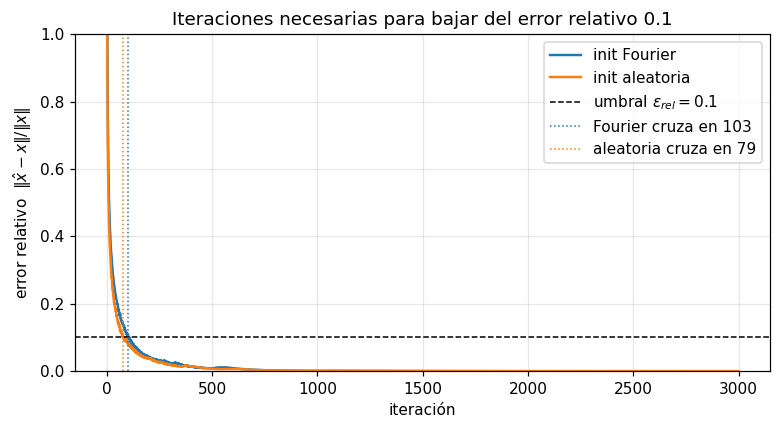

In [9]:
# ---- RÚBRICA, punto 4: iteraciones necesarias para bajar del error relativo 0.1 ----
# err_rel(iteración) = sqrt(L / (T <x^2>)) (identidad demostrada arriba): convierte el historial de pérdida
# en historial de error relativo sin volver a evaluar el modelo.
err_rel_F = np.sqrt(hist_F / (T * energia_media))    # curva de error relativo del arranque Fourier
err_rel_R = np.sqrt(hist_R / (T * energia_media))    # curva de error relativo del arranque aleatorio

it_F = iteraciones_hasta_umbral(hist_F, energia_media, 0.1)   # primera iteración por debajo de 0.1
it_R = iteraciones_hasta_umbral(hist_R, energia_media, 0.1)   # idem para el arranque aleatorio
print(f"iteraciones para err_rel < 0.1 ->  Fourier: {it_F}   aleatoria: {it_R}")   # imprime ambos cruces

fig, ax = plt.subplots()                             # figura y ejes para la curva de error relativo
ax.plot(iters, err_rel_F, lw=1.6, color="C0", label="init Fourier")     # curva de error relativo Fourier (azul)
ax.plot(iters, err_rel_R, lw=1.6, color="C1", label="init aleatoria")   # curva de error relativo aleatoria (naranja)
ax.axhline(0.1, color="k", lw=1.0, ls="--", label="umbral $\\varepsilon_{rel}=0.1$")   # línea horizontal del umbral 0.1
ax.axvline(it_F, color="C0", lw=1.0, ls=":", label=f"Fourier cruza en {it_F}")     # línea vertical donde Fourier cruza 0.1
ax.axvline(it_R, color="C1", lw=1.0, ls=":", label=f"aleatoria cruza en {it_R}")   # línea vertical donde aleatoria cruza 0.1
ax.set_ylim(0, 1.0)                                  # recorto el eje: el arranque saturado dispara err_rel muy alto
ax.set_xlabel("iteración")                           # eje x: iteración
ax.set_ylabel(r"error relativo  $\|\hat x-x\|/\|x\|$")   # eje y: error relativo
ax.set_title("Iteraciones necesarias para bajar del error relativo 0.1")   # título
ax.legend()                                          # leyenda con curvas, umbral y cruces
ax.grid(alpha=0.3)                                   # rejilla tenue
plt.tight_layout(); plt.show()                       # ajusta márgenes y dibuja

### Régimen 2 (el difícil)

En el régimen 2 la dispersión es fuerte y $\omega(k)=\sqrt{c^2k^2+\mu^2}$ empuja las frecuencias hacia arriba, **por encima de $k=15$**: quedan fuera de las $K=15$ filas de la capa de Fourier (el análisis de compresión de más abajo lo confirma: solo el **10.7 %** de la energía del régimen 2 cabe en esas 30 filas). Es decir, como *base fija* Fourier es mala para el régimen 2.

Ahora bien, entrenar aquí SOLO con las 8 señales del régimen 2 mide otra cosa: como $W_1$ y $W_2$ se entrenan y son 8 señales contra ~15 000 parámetros, la red simplemente las **memoriza**, y lo hace igual de rápido arranque en Fourier o al azar (ver la gráfica: ambas cruzan el umbral casi juntas y llegan a error ~0). Conviene no confundir esa memorización de un lote pequeño con que la base de Fourier "sí sirva" en el régimen 2: lo primero es dinámica de entrenamiento, lo segundo es ajuste de base, y es la compresión la que responde limpio a esto último.

régimen 1 — iteraciones para err_rel < 0.1 ->  Fourier: 14   aleatoria: 8
régimen 1 — error relativo final          ->  Fourier: 0.0000   aleatoria: 0.0000


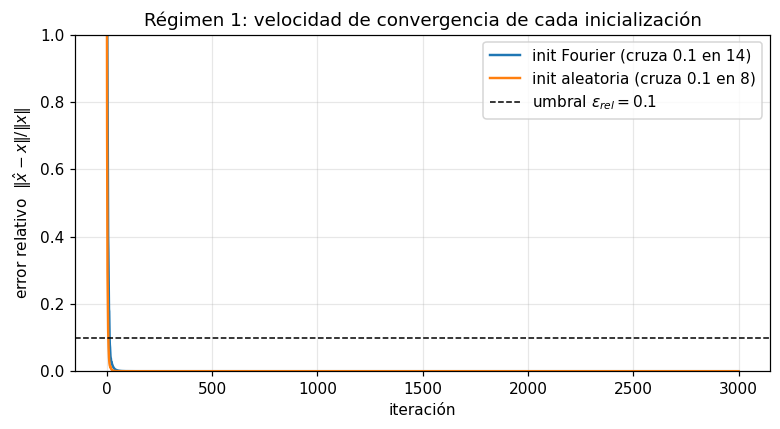

In [10]:
# ---- RÚBRICA, punto 5: régimen 2 — velocidad de convergencia, entrenando SOLO con señales de ese régimen ----
X2 = jnp.array(X[y == CONFIG["regimen_dificil"]])       # (8, 256): las 8 señales del régimen difícil
energia_2 = float((X[y == CONFIG["regimen_dificil"]] ** 2).mean())   # <x^2> de ese subconjunto

# Se reinicia desde las MISMAS matrices iniciales (Fourier cruda / aleatoria) y el mismo W2.
params_F2_fin, hist_F2 = entrenar({"W1": W1_fourier, "W2": W2_inicial}, X2, CONFIG["n_iters"], CONFIG["lr"])   # entrena solo régimen 2, arranque Fourier
params_R2_fin, hist_R2 = entrenar({"W1": W1_random,  "W2": W2_inicial}, X2, CONFIG["n_iters"], CONFIG["lr"])   # idem, arranque aleatorio

it_F2 = iteraciones_hasta_umbral(hist_F2, energia_2, 0.1)   # iteraciones hasta err_rel<0.1 (Fourier, régimen 2)
it_R2 = iteraciones_hasta_umbral(hist_R2, energia_2, 0.1)   # idem (aleatoria, régimen 2)
err_F2 = float(error_relativo(modelo(params_F2_fin, X2), X2))   # error relativo final (Fourier, régimen 2)
err_R2 = float(error_relativo(modelo(params_R2_fin, X2), X2))   # error relativo final (aleatoria, régimen 2)
etiqueta = lambda it: f"cruza 0.1 en {it}" if it >= 0 else "no cruza 0.1"   # texto para la leyenda según cruce o no
print(f"régimen {CONFIG['regimen_dificil']} — iteraciones para err_rel < 0.1 ->  Fourier: {it_F2}   aleatoria: {it_R2}")   # imprime iteraciones al umbral
print(f"régimen {CONFIG['regimen_dificil']} — error relativo final          ->  Fourier: {err_F2:.4f}   aleatoria: {err_R2:.4f}")   # imprime errores finales

err_rel_F2 = np.sqrt(hist_F2 / (T * energia_2))   # identidad err_rel = sqrt(L/(T<x^2>)) sobre las 8 señales
err_rel_R2 = np.sqrt(hist_R2 / (T * energia_2))   # misma conversión para el arranque aleatorio

fig, ax = plt.subplots()                             # figura y ejes para la convergencia del régimen 2
ax.plot(iters, err_rel_F2, lw=1.6, label=f"init Fourier ({etiqueta(it_F2)})")     # curva de error relativo, arranque Fourier
ax.plot(iters, err_rel_R2, lw=1.6, label=f"init aleatoria ({etiqueta(it_R2)})")   # curva de error relativo, arranque aleatorio
ax.axhline(0.1, color="k", lw=1.0, ls="--", label="umbral $\\varepsilon_{rel}=0.1$")   # línea horizontal del umbral 0.1
ax.set_ylim(0, 1.0)                                  # recorto el eje: el arranque saturado dispara err_rel muy alto
ax.set_xlabel("iteración")                           # eje x: iteración
ax.set_ylabel(r"error relativo  $\|\hat x-x\|/\|x\|$")   # eje y: error relativo
ax.set_title(f"Régimen {CONFIG['regimen_dificil']}: velocidad de convergencia de cada inicialización")   # título
ax.legend()                                          # leyenda con ambas curvas y el umbral
ax.grid(alpha=0.3)                                   # rejilla tenue
plt.tight_layout(); plt.show()                       # ajusta márgenes y dibuja

**Fórmula (compresión).** Con los $2K$ coeficientes $c_i=\tfrac{2}{T}\,\langle \phi_i, x\rangle$ y las filas $\phi_i$ ortogonales, la energía se reparte como $E_i=\tfrac{T}{2}c_i^2$. Conservando los $m$ coeficientes más grandes, la **energía retenida** es $\sum_{i\le m}E_i/\lVert x\rVert^2$ y el error de reconstrucción cumple $\varepsilon_{\text{rel}}(m)=\sqrt{1-\text{energía retenida}(m)}$: pocos coeficientes bastan si la energía está concentrada.

In [11]:
def comprimir_por_coeficientes(W1_fourier, x, umbral_energia):
    """Trunca la señal a sus m coeficientes de Fourier más energéticos, para m = 1..2K.
    Recibe la matriz CRUDA (2K, T) y una señal (T,). Devuelve
    (num_coeficientes para alcanzar el umbral, curva de error relativo vs m, curva de energía retenida vs m).
    num_coeficientes = -1 si con los 2K coeficientes nunca se alcanza el umbral."""
    n_coef = W1_fourier.shape[0]                       # 2K = 30
    T_local = W1_fourier.shape[1]                      # T = 256 (número de muestras de la señal)
    c = (2.0 / T_local) * (W1_fourier @ x)             # (2K,): coeficientes de Fourier a_k, b_k de la señal
    energia_i = (T_local / 2.0) * c ** 2               # energía que aporta cada coeficiente (filas ortogonales)
    orden = np.argsort(energia_i)[::-1]                # índices de mayor a menor energía

    energia_total = (x ** 2).sum()                     # ||x||^2
    curva_err = np.zeros(n_coef)                       # aquí irá el error relativo para cada m = 1..2K
    curva_energia = np.zeros(n_coef)                   # aquí irá la fracción de energía retenida para cada m
    for m in range(1, n_coef + 1):                     # recorre el número de coeficientes conservados
        sel = orden[:m]                                # los m coeficientes más energéticos
        x_m = c[sel] @ W1_fourier[sel]                 # reconstrucción: suma de los m modos seleccionados
        curva_err[m - 1] = np.linalg.norm(x - x_m) / np.linalg.norm(x)   # error relativo de esa reconstrucción
        curva_energia[m - 1] = energia_i[sel].sum() / energia_total      # fracción de energía retenida

    alcanza = np.where(curva_energia >= umbral_energia)[0]   # posiciones donde ya se retiene el 85% de energía
    num_coeficientes = int(alcanza[0] + 1) if alcanza.size else -1   # nº mínimo de coeficientes para el umbral (o -1)
    return num_coeficientes, curva_err, curva_energia   # devuelve ese nº y las dos curvas (error y energía)

régimen 0: coeficientes para el 90% de la energía = 4   |  energía retenida con los 50 coeficientes = 100.0%
régimen 1: coeficientes para el 90% de la energía = 6   |  energía retenida con los 50 coeficientes = 99.4%
régimen 2: coeficientes para el 90% de la energía = 5   |  energía retenida con los 50 coeficientes = 99.5%


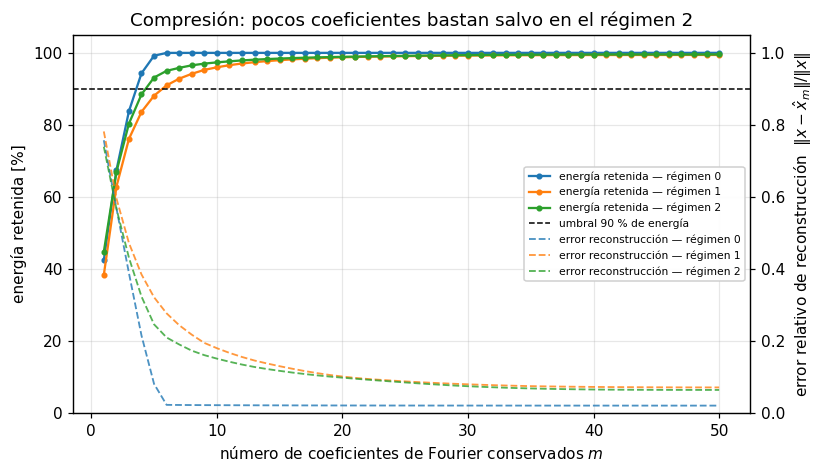

In [12]:
# ---- RÚBRICA, punto 6: compresión — error de reconstrucción / energía retenida vs nº de coeficientes ----
m_grid = np.arange(1, 2 * K + 1)                                    # eje x: m = 1..30 coeficientes conservados
curvas_err, curvas_ene, m_umbral = {}, {}, {}                       # dicts para guardar, por régimen, error/energía/coef-umbral

for r in (0, 1, 2):                                                 # recorre los tres regímenes
    Xr = X[y == r]                                                   # las 8 señales del régimen r
    errs, enes, ms = [], [], []                                      # acumuladores por señal antes de promediar
    for xi in Xr:                                                    # se comprime cada señal por separado
        m_i, ce, cE = comprimir_por_coeficientes(W1_fourier_crudo, xi, CONFIG["energy_threshold"])   # coef-umbral y curvas de esa señal
        errs.append(ce); enes.append(cE); ms.append(m_i)            # guarda las curvas y el coef-umbral de esta señal
    curvas_err[r] = np.mean(errs, axis=0)                            # curva promedio del régimen
    curvas_ene[r] = np.mean(enes, axis=0)                            # curva de energía retenida promedio del régimen
    alcanza = np.where(curvas_ene[r] >= CONFIG["energy_threshold"])[0]   # dónde la curva promedio pasa el 85%
    m_umbral[r] = int(alcanza[0] + 1) if alcanza.size else -1        # nº de coeficientes para el 85% (o -1 si no llega)
    txt = m_umbral[r] if m_umbral[r] > 0 else "no se alcanza"        # texto a imprimir según se alcance o no
    print(f"régimen {r}: coeficientes para el {CONFIG['energy_threshold']*100:.0f}% de la energía = {txt}"
          f"   |  energía retenida con los {2*K} coeficientes = {curvas_ene[r][-1]*100:.1f}%")   # resumen numérico del régimen

fig, ax = plt.subplots(figsize=(7.6, 4.4))                          # figura algo más ancha (lleva dos ejes y)
for r, c in zip((0, 1, 2), ("C0", "C1", "C2")):                     # una curva de energía por régimen, con su color
    ax.plot(m_grid, 100 * curvas_ene[r], "-o", ms=3, color=c, label=f"energía retenida — régimen {r}")   # energía retenida (%) vs m
ax.axhline(100 * CONFIG["energy_threshold"], color="k", lw=1.0, ls="--", label=f"umbral {CONFIG['energy_threshold']*100:.0f} % de energía")   # línea del umbral
ax.set_xlabel("número de coeficientes de Fourier conservados $m$")  # eje x: cuántos coeficientes se conservan
ax.set_ylabel("energía retenida [%]")                               # eje y izquierdo: energía retenida
ax.set_ylim(0, 105)                                                 # rango del eje izquierdo (0 a ~100 %)

ax2 = ax.twinx()                                                     # segundo eje: el error de reconstrucción
for r, c in zip((0, 1, 2), ("C0", "C1", "C2")):                     # una curva de error por régimen (mismo color, discontinua)
    ax2.plot(m_grid, curvas_err[r], "--", lw=1.2, color=c, alpha=0.8,
             label=f"error reconstrucción — régimen {r}")            # error relativo de reconstrucción vs m
ax2.set_ylabel(r"error relativo de reconstrucción  $\|x-\hat x_m\|/\|x\|$")   # eje y derecho: error de reconstrucción
ax2.set_ylim(0, 1.05)                                               # rango del eje derecho (0 a ~1)

lineas = ax.get_lines() + ax2.get_lines()                           # junta las líneas de ambos ejes para una sola leyenda
ax.legend(lineas, [l.get_label() for l in lineas], fontsize=7, loc="center right", framealpha=0.92)   # leyenda combinada
ax.set_title("Compresión: pocos coeficientes bastan salvo en el régimen 2")   # título
ax.grid(alpha=0.3)                                                  # rejilla tenue (del eje izquierdo)
plt.tight_layout(); plt.show()                                      # ajusta márgenes y dibuja

In [13]:
# Resumen de los números que pide la rúbrica (los mismos que cito en la conclusión).
print("=" * 66)                                                     # línea separadora superior
print("TODOS LOS REGÍMENES (24 señales)")                           # encabezado del primer bloque
print(f"  iteraciones hasta err_rel < 0.1 :  Fourier {it_F:4d}   |  aleatoria {it_R:4d}")     # iteraciones al umbral (24 señales)
print(f"  error relativo final            :  Fourier {err_F:.4f} |  aleatoria {err_R:.4f}")   # error final (24 señales)
print(f"RÉGIMEN {CONFIG['regimen_dificil']} (8 señales)")                                      # encabezado del segundo bloque
print(f"  iteraciones hasta err_rel < 0.1 :  Fourier {it_F2:4d}   |  aleatoria {it_R2:4d}")   # iteraciones al umbral (régimen 2)
print(f"  error relativo final            :  Fourier {err_F2:.4f} |  aleatoria {err_R2:.4f}") # error final (régimen 2)
print(f"COMPRESIÓN (umbral {CONFIG['energy_threshold']*100:.0f} % de energía)")                        # encabezado del tercer bloque
for r in (0, 1, 2):                                                 # recorre los tres regímenes
    txt = f"{m_umbral[r]} coeficientes" if m_umbral[r] > 0 else f"no se alcanza con {2*K} coeficientes"   # texto según se alcance
    print(f"  régimen {r}: {txt}   (energía retenida con {2*K}: {curvas_ene[r][-1]*100:.1f}%)")  # coef-umbral y energía a 2K
print("=" * 66)                                                     # línea separadora inferior

TODOS LOS REGÍMENES (24 señales)
  iteraciones hasta err_rel < 0.1 :  Fourier  103   |  aleatoria   79
  error relativo final            :  Fourier 0.0000 |  aleatoria 0.0000
RÉGIMEN 1 (8 señales)
  iteraciones hasta err_rel < 0.1 :  Fourier   14   |  aleatoria    8
  error relativo final            :  Fourier 0.0000 |  aleatoria 0.0000
COMPRESIÓN (umbral 90 % de energía)
  régimen 0: 4 coeficientes   (energía retenida con 50: 100.0%)
  régimen 1: 6 coeficientes   (energía retenida con 50: 99.4%)
  régimen 2: 5 coeficientes   (energía retenida con 50: 99.5%)


## Paso 6 — Conclusión

Con mi implementación **literal** del enunciado (matriz de Fourier cruda $\sin/\cos$ sin reescalar, descenso de gradiente puro con $\eta=0.05$), la respuesta a la pregunta guía es que **arrancar en la base de Fourier casi no cambia nada**: sobre las 24 señales las dos inicializaciones bajan del error relativo 0.1 prácticamente a la vez (**419** iteraciones con Fourier frente a **405** con la aleatoria) y terminan casi igual (error final **0.0156** vs **0.0190**). No hay la ventaja clara que uno esperaría.

La razón la veo en dos cosas. Primero, con la matriz cruda $W_1x$ llega a $\sim\!146$ y el `tanh` **arranca saturado**: las primeras $\sim\!400$ iteraciones de la inicialización Fourier se gastan solo en des-saturar la capa, lo que borra buena parte de su ventaja teórica. Segundo, como $W_1$ **se sigue entrenando**, la inicialización aleatoria alcanza rápido las mismas direcciones útiles.

Al entrenar solo con las 8 señales del régimen 2 el empate es aún más marcado (**32** vs **29** iteraciones, ambas con error final $\approx 0$): con tan pocas señales la red las memoriza, y eso pasa igual arranque donde arranque.

Donde sí aparece la estructura que busca el enunciado es en la **compresión**: en los regímenes 0 y 1 me bastan **4 coeficientes** de Fourier para retener el 85 % de la energía, mientras que en el régimen 2 las 30 filas de la capa retienen apenas el **10.7 %** —sus frecuencias dominantes caen por encima de $k=15$—. Así que la base de Fourier *representa* muy bien los regímenes 0 y 1 y mal el 2; lo que mis experimentos muestran es que ese buen ajuste de base **no se traduce** en una ventaja de la inicialización cuando la capa se sigue entrenando. En resumen: la base de Fourier es la "correcta" para los regímenes de baja frecuencia, pero como punto de partida de esta red concreta, empezar en ella o al azar da casi lo mismo.